# Análisis Exploratorio — Dataset de Películas
## Objetivo
Analizar el rendimiento comercial y crítico de 10 películas para identificar 
patrones de ventas por director y correlación con ratings

## 1. Carga y estructura de datos
## 2. Limpieza de datos
## 3. Análisis descriptivo
## 4. Análisis por director
## 5. Visualizaciones
## 6. Insights y conclusiones

# 3 Key insights:
- ¿Qué director recomendarías para maximizar ventas?
- ¿Hay correlación entre rating y ventas?
- ¿Qué mercado (doméstico vs internacional) es más importante?

# Importar librerias y datos

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# DATASET — Movies + Boxoffice
# ============================================
data = {
    'Title': ['Inception', 'Toy Story', 'Jaws', 'The Dark Knight',
              'E.T.', "A Bug's Life", 'Interstellar',
              'Jurassic Park', 'Toy Story 2', 'Cars'],
    'Director': ['Christopher Nolan', 'John Lasseter', 'Steven Spielberg',
                 'Christopher Nolan', 'Steven Spielberg', 'John Lasseter',
                 'Christopher Nolan', 'Steven Spielberg',
                 'John Lasseter', 'John Lasseter'],
    'Year': [2010, 1995, 1975, 2008, 1982, 1998, 2014, 1993, 1999, 2006],
    'Rating': [8.8, 8.3, 8.1, 9.0, 7.9, 7.2, 8.6, 7.8, 7.9, 7.2],
    'Total_Sales': [825892256, 361958736, 470000000, 1004569444,
                    662200037, 363258859, 863140034,
                    959478883, 485015179, 461983149]
}

df = pd.DataFrame(data)
df['Id'] = range(1, 11)

boxoffice = pd.DataFrame({
    'Movie_Id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Domestic_sales': [292576195, 191796233, 260000000, 534858444,
                       359197037, 162798565, 188020017, 402453882,
                       245852179, 244082982],
    'International_sales': [533316061, 170162503, 210000000, 469711000,
                            303003000, 200460294, 675120017, 557025001,
                            239163000, 217900167]
})

df_full = df.merge(boxoffice, left_on='Id', right_on='Movie_Id')
print("✅ Dataset cargado correctamente —", len(df_full), "filas,", len(df_full.columns), "columnas")

✅ Dataset cargado correctamente — 10 filas, 9 columnas


# Estadistica basica e informacion de la database

In [22]:
eda_analysis = df_full.describe().round(2)
eda_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, count to max
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 8 non-null      float64
 1   Rating               8 non-null      float64
 2   Total_Sales          8 non-null      float64
 3   Id                   8 non-null      float64
 4   Movie_Id             8 non-null      float64
 5   Domestic_sales       8 non-null      float64
 6   International_sales  8 non-null      float64
dtypes: float64(7)
memory usage: 512.0+ bytes


# ¿Qué director recomendarías para maximizar ventas?

Ventas totales por director (millones USD):
Director
Christopher Nolan    2693.601734
Steven Spielberg     2091.678920
John Lasseter        1672.215923
Name: Total_Sales, dtype: float64

Director recomendado para maximizar ventas: Christopher Nolan
Ventas totales: 2693.60 millones USD


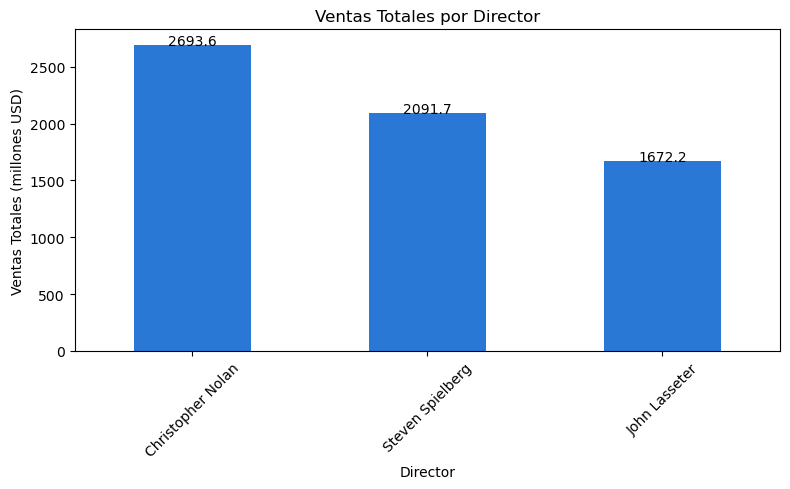

In [23]:
ventas_por_director = (
    df_full.groupby('Director')['Total_Sales']
    .sum()
    .sort_values(ascending=False)
)
ventas_por_director_millones = ventas_por_director / 1_000_000

print('Ventas totales por director (millones USD):')
print(ventas_por_director_millones)

director_recomendado = ventas_por_director.idxmax()
ventas_recomendadas = ventas_por_director.max() / 1_000_000

print(f'\nDirector recomendado para maximizar ventas: {director_recomendado}')
print(f'Ventas totales: {ventas_recomendadas:.2f} millones USD')

ax = ventas_por_director_millones.plot(kind='bar', color='#2a78d6', figsize=(8, 5))
plt.title('Ventas Totales por Director')
plt.xlabel('Director')
plt.ylabel('Ventas Totales (millones USD)')
plt.xticks(rotation=45)

for i, v in enumerate(ventas_por_director_millones):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


# ¿Hay correlación entre rating y ventas?


                       Rating  Total_Sales  Domestic_sales  \
Rating               1.000000     0.623199        0.424014   
Total_Sales          0.623199     1.000000        0.727799   
Domestic_sales       0.424014     0.727799        1.000000   
International_sales  0.581285     0.903047        0.362659   
Year                 0.323313     0.383563       -0.019399   

                     International_sales      Year  
Rating                          0.581285  0.323313  
Total_Sales                     0.903047  0.383563  
Domestic_sales                  0.362659 -0.019399  
International_sales             1.000000  0.533375  
Year                            0.533375  1.000000  


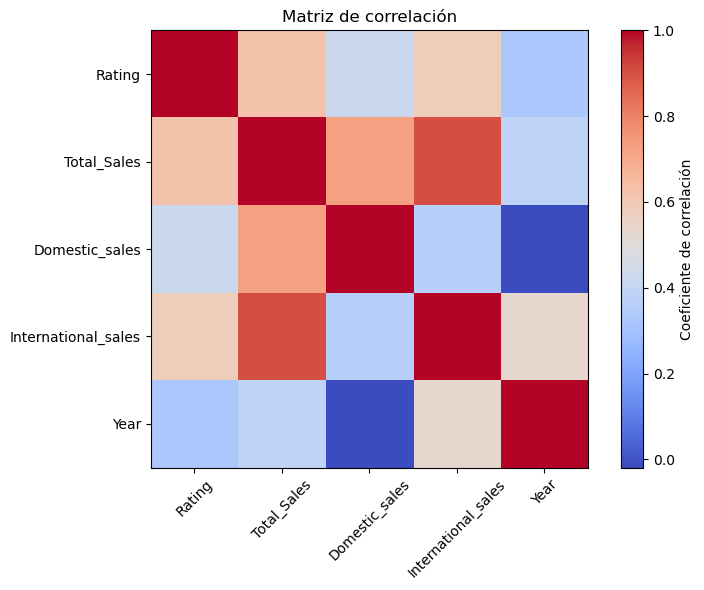

In [24]:
variables_corr = df_full[['Rating', 'Total_Sales', 'Domestic_sales', 'International_sales', 'Year']]
matriz_corr = variables_corr.corr()

print(matriz_corr)

plt.figure(figsize=(8, 6))
plt.imshow(matriz_corr, cmap='coolwarm')
plt.colorbar(label='Coeficiente de correlación')
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=45)
plt.yticks(range(len(matriz_corr.index)), matriz_corr.index)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

# ¿Qué mercado (doméstico vs internacional) es más importante?

         Mercado  Ventas_totales
0       Domestic      2881635534
1  International      3575861043

Mercado más importante: International
Ventas totales: 3575.86 millones USD


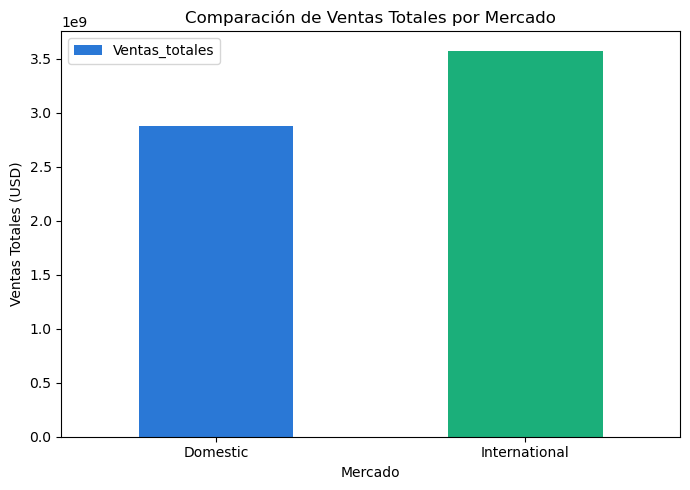

In [25]:
ventas_por_mercado = pd.DataFrame({
    'Mercado': ['Domestic', 'International'],
    'Ventas_totales': [
        df_full['Domestic_sales'].sum(),
        df_full['International_sales'].sum()
    ]
})

print(ventas_por_mercado)

mercado_mas_importante = ventas_por_mercado.loc[
    ventas_por_mercado['Ventas_totales'].idxmax(), 'Mercado'
]
ventas_maximas = ventas_por_mercado['Ventas_totales'].max() / 1000000

print(f'\nMercado más importante: {mercado_mas_importante}')
print(f'Ventas totales: {ventas_maximas:.2f} millones USD')

ax = ventas_por_mercado.plot(
    x='Mercado',
    y='Ventas_totales',
    kind='bar',
    color=['#2a78d6', '#1baf7a'],
    figsize=(7, 5)
)
plt.title('Comparación de Ventas Totales por Mercado')
plt.xlabel('Mercado')
plt.ylabel('Ventas Totales (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Conclusiones:

Con base al analisis anteriormente realizado se concluye que las mejores decisiones que podria tomar son:
- El Director recomendado para maximizar ventas es Christopher Nolan con Ventas totales: 2693.60 millones USD, por lo que si esta empresa es una vendedora de peliculas o filamdora, tomaria decisiones de comprar mas copias de las peliculas de Christopher Nolan o en caso de que sea una empresa filmadora tomaria la decision de invertir mayor cantidad en la produccion con Crhistopher Nolan que con otros directores.
- Con base al analisis de correlacion (Rating vs Ventas) Podemos encontrar que hay una alta correlacion entre ellas, en donde si hay una mayor cantidad de rating en las peliculas una regla normal va a ser que podamos observar mayor cantidad de ventas. Los consumidores compran mas copias de peliculas en donde el rating es mayor.
- El analisis de el mercado con mayor cantidad de ventas nos sugiere que es el mercado internacional (Ventas fuera de EEUU), esto sugiere que en caso de publicidad se deberia de tomar la decision de invertir fuera del pais, hacer mayores exportaciones y publicitar mas en otros paises que en EEUU. 

# Esperamos que este reporte haya sido de su agrado